/tmp/ipykernel_16350/210983485.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2020-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Downloaded 756 data points for AAPL
Training samples: 556, Test samples: 140
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0937 - val_loss: 0.0092
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0090 - val_loss: 0.0085
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0043 - val_loss: 0.0048
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0025 - val_loss: 0.0044
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0020 - val_loss: 0.0040
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0017 - val_loss: 0.0041
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0017 - val_loss: 0.0040
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0016 - val_loss: 0.0041
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0016 - val_loss: 0.0039
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0016 - val_loss: 0.0041
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0016 - val

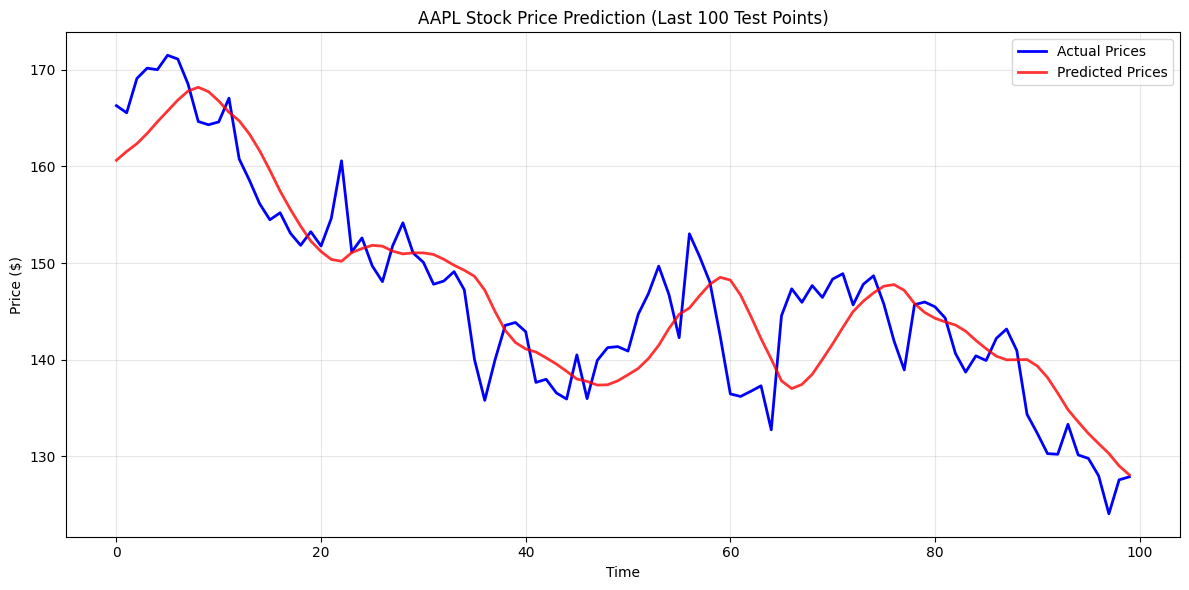


What would you like to do?
1. Make next day prediction
2. View prediction plot
3. Exit


In [ ]:
#The code uses yfinance library which automatically downloads stock data from Yahoo Finance
#LSTM stock prediction model
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import yfinance as yf
import matplotlib.pyplot as plt

# Download dataset with default parameters
data = yf.download('AAPL', start='2020-01-01', end='2023-01-01')
prices = data['Close'].values.reshape(-1, 1)
print(f"Downloaded {len(prices)} data points for AAPL")

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(prices)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Prepare data
seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

# Split data
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

# Build LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50, return_sequences=False),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train model with early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=50,               # Set higher max epochs
    batch_size=32,
    verbose=1,
    validation_split=0.1,
    callbacks=[early_stopping] # Add early stopping
)

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test)

# Model Evaluation
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, predictions)
r2 = r2_score(actual, predictions)

# Calculate directional accuracy
actual_direction = np.diff(actual.flatten()) > 0
pred_direction = np.diff(predictions.flatten()) > 0
directional_accuracy = accuracy_score(actual_direction, pred_direction) * 100

# Calculate price range accuracy (within 5% threshold)
price_diff = np.abs(actual - predictions) / actual
accuracy_5pct = np.mean(price_diff <= 0.05) * 100

print(f"\n" + "=" * 40)
print(f"MODEL EVALUATION RESULTS")
print(f"=" * 40)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Directional Accuracy: {directional_accuracy:.2f}%")
print(f"Price Accuracy (±5%): {accuracy_5pct:.2f}%")

# User interaction
while True:
    print(f"\nWhat would you like to do?")
    print("1. Make next day prediction")
    print("2. View prediction plot")
    print("3. Exit")

    choice = input("Enter your choice (1-4): ")

    if choice == '1':
        # Make prediction for next day
        last_sequence = X_test[-1].reshape(1, seq_length, 1)
        next_price = model.predict(last_sequence, verbose=0)
        next_price = scaler.inverse_transform(next_price)
        current_price = actual[-1][0]
        predicted_price = next_price[0][0]

        print(f"\n" + "=" * 30)
        print(f"NEXT DAY PREDICTION")
        print(f"=" * 30)
        print(f"Current price: ${current_price:.2f}")
        print(f"Predicted price: ${predicted_price:.2f}")
        print(f"Expected change: {((predicted_price - current_price) / current_price) * 100:.2f}%")

        if predicted_price > current_price:
            print("Direction: UP")
        else:
            print("Direction: DOWN")

    elif choice == '2':
        # Show plot
        plt.figure(figsize=(12, 6))
        plt.plot(actual[-100:], label='Actual Prices', color='blue', linewidth=2)
        plt.plot(predictions[-100:], label='Predicted Prices', color='red', linewidth=2, alpha=0.8)
        plt.title(f'AAPL Stock Price Prediction (Last 100 Test Points)')
        plt.xlabel('Time')
        plt.ylabel('Price ($)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    elif choice == '3':
        print("Goodbye!")
        break

    else:
        print("Invalid choice. Please try again.")